# S7: Introduction to Computer Vision with CNNs, Transfer Learning, and Fine-tuning

For a detailed explanation of the concepts and intuition, please refer to the lecture slides available at: https://docs.google.com/presentation/d/1eCp89vVcyKy5r-zyzrHECJUHQ87WC6bSHB2s3xdPJto/edit?usp=sharing.

Before you begin, it's recommended to make a copy of this notebook, as any changes you make won't be saved when the page is refreshed. Additionally, to optimize performance, switch the runtime type to use a GPU by navigating to **Runtime -> Change runtime type**, and then select your preferred GPU option under the **Hardware accelerator** section.

## Loading and Preprocessing Image

In this demonstration, we will be performing visual-based document classification. The dataset consists of three categories of documents: emails, resumes, and scientific applications. Our objective is to classify these documents based on their visual appearance using image classification techniques.

In [1]:
# Download the dataset using Kaggle CLI
!kaggle datasets download ritvik1909/document-classification-dataset

Dataset URL: https://www.kaggle.com/datasets/ritvik1909/document-classification-dataset
License(s): CC0-1.0
document-classification-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [2]:
# Extract the downloaded file (ZIP)
!unzip -o document-classification-dataset.zip -d data

Archive:  document-classification-dataset.zip
  inflating: data/email/doc_000042.png  
  inflating: data/email/doc_000046.png  
  inflating: data/email/doc_000076.png  
  inflating: data/email/doc_000079.png  
  inflating: data/email/doc_000111.png  
  inflating: data/email/doc_000115.png  
  inflating: data/email/doc_000133.png  
  inflating: data/email/doc_000142.png  
  inflating: data/email/doc_000148.png  
  inflating: data/email/doc_000165.png  
  inflating: data/email/doc_000195.png  
  inflating: data/email/doc_000196.png  
  inflating: data/email/doc_000238.png  
  inflating: data/email/doc_000255.png  
  inflating: data/email/doc_000260.png  
  inflating: data/email/doc_000275.png  
  inflating: data/email/doc_000278.png  
  inflating: data/email/doc_000279.png  
  inflating: data/email/doc_000282.png  
  inflating: data/email/doc_000297.png  
  inflating: data/email/doc_000333.png  
  inflating: data/email/doc_000347.png  
  inflating: data/email/doc_000363.png  
  inflating

In [3]:
# We will load dataset using API from TensorFlow
import tensorflow as tf

In [4]:
# Dataset location (where we previously extract to)
dataset_directory = "./data"

# Hyperparameters
batch_size = 32
img_height = 224
img_width = 224

In [5]:
# Load the training dataset (Train:Valid = 80:20)
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(

)

# Load the testing dataset (Note: We don't usually shuffle the testing set)
validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(

)

Found 165 files belonging to 3 classes.
Using 132 files for training.
Found 165 files belonging to 3 classes.
Using 33 files for validation.


**Note**: These 3 classes are encoded as 0, 1, and 2. The order of labels corresponds to the alphabetical labels in the ascending order. In this case, email (0), resume (1), and scientific publication (2).

In [6]:
# Preprocess the images (normalization)
normalization_layer = tf.keras.layers.Rescaling()

# Perform normalization on the dataset by mapping the layers
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
validation_dataset = validation_dataset.map(lambda x, y: (normalization_layer(x), y))

## Training CNN From Scratch

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

In [8]:
# Create a function to build CNN and build our first model
def build_cnn(input_shape, num_classes):
    return

In [9]:
model = build_cnn(input_shape=(img_height, img_width, 3), num_classes=3)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 186624)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      47,776,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 47,796,163 (182.33 MB)

 Trainable params: 47,796,163 (182.33 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Training the model
epochs = 20
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs,
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.3092 - loss: 27.6115 - val_accuracy: 0.0000e+00 - val_loss: 7.5847
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - accuracy: 0.3334 - loss: 3.5590 - val_accuracy: 0.0606 - val_loss: 0.9484
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.3598 - loss: 1.0872 - val_accuracy: 0.9697 - val_loss: 0.6134
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.5847 - loss: 0.8862 - val_accuracy: 1.0000 - val_loss: 0.0792
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.5800 - loss: 0.9707 - val_accuracy: 1.0000 - val_loss: 0.0065
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.5381 - loss: 1.2200 - val_accuracy: 0.6667 - val_loss: 0.5786
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.7872 - loss: 0.5424 - val_accuracy: 0.9394 - val_loss: 0.2138
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 200ms/step - accuracy: 0.9049 - loss: 0.3127 - val_accuracy: 0.3030 - val_lo

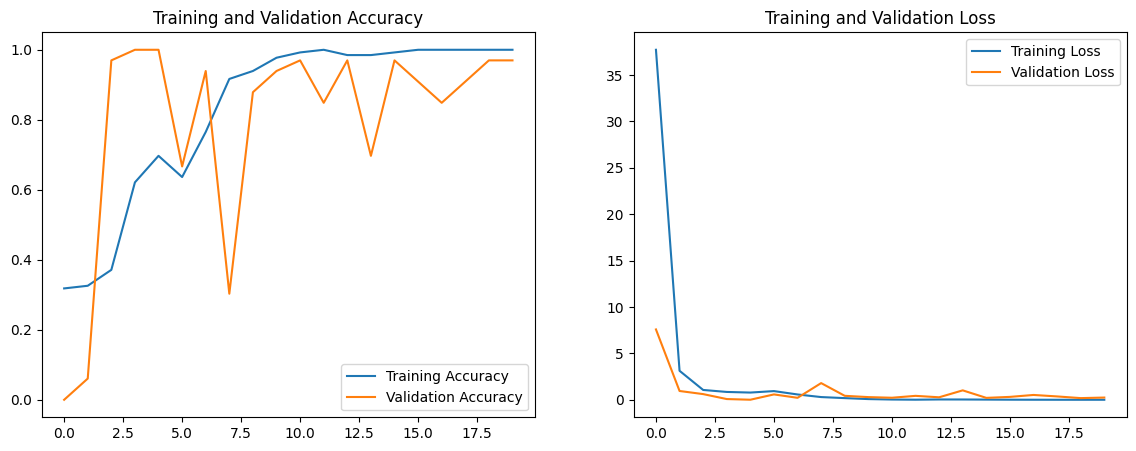

In [11]:
# Function to plot loss and accuracy curves
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.show()

plot_training_history(history)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 333ms/step


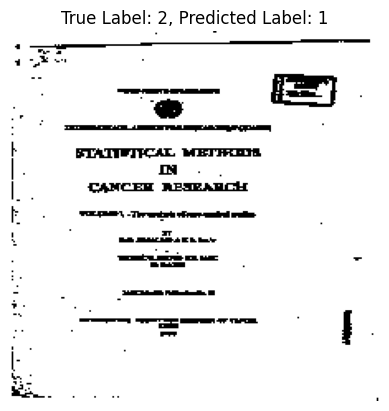

In [12]:
# Get model predictions on the validation dataset
predictions = model.predict(validation_dataset)
predicted_classes = np.argmax(predictions, axis=1)

# Get the true labels from the validation dataset
true_labels = []
for _, labels in validation_dataset:
    true_labels.extend(labels.numpy())

# Convert true_labels to a numpy array for easier comparison
true_labels = np.array(true_labels)

# Find the indices of misclassified images
misclassified_indices = np.where(predicted_classes != true_labels)[0]

# Visualize some misclassified images
num_images_to_visualize = 5
for i in range(min(num_images_to_visualize, len(misclassified_indices))):
    index = misclassified_indices[i]
    image, label = list(validation_dataset)[0][0][index], list(validation_dataset)[0][1][index]

    plt.imshow(image.numpy().astype("uint8") * 255)
    plt.title(f"True Label: {label.numpy()}, Predicted Label: {predicted_classes[index]}")
    plt.axis('off')
    plt.show()

# Fine-tuning Famous CNNs: VGGNet and EfficientNet

### VGG16
Simonyan, K., & Zisserman, A. (2014, September 4). Very deep convolutional networks for Large-Scale image recognition. arXiv.org. https://arxiv.org/abs/1409.1556

In [13]:
# Load VGG16 without top layers
base_model_vgg = None

# Freeze the base models
base_model_vgg.trainable = False

# Create the model
model_vgg = None

# Compile the model
model_vgg.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Summary of the model
model_vgg.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,846,787 (56.64 MB)

 Trainable params: 132,099 (516.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [14]:
# Train the model
epochs = 20
history_vgg = model_vgg.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs,
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.3825 - loss: 1.2228 - val_accuracy: 0.4242 - val_loss: 0.9247
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 170ms/step - accuracy: 0.4781 - loss: 0.9883 - val_accuracy: 0.6970 - val_loss: 0.9017
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - accuracy: 0.7868 - loss: 0.8239 - val_accuracy: 0.5455 - val_loss: 1.0314
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.7013 - loss: 0.7690 - val_accuracy: 0.6667 - val_loss: 0.9162
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 309ms/step - accuracy: 0.8088 - loss: 0.6395 - val_accuracy: 0.7576 - val_loss: 0.7094
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 334ms/step - accuracy: 0.8577 - loss: 0.5712 - val_accuracy: 0.9394 - val_loss: 0.3917
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - accuracy: 0.8727 - loss: 0.5677 - val_accuracy: 0.9091 - val_loss: 0.3847
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - accuracy: 0.9150 - loss: 0.4785 - val_accuracy: 0.7879 - val_loss: 

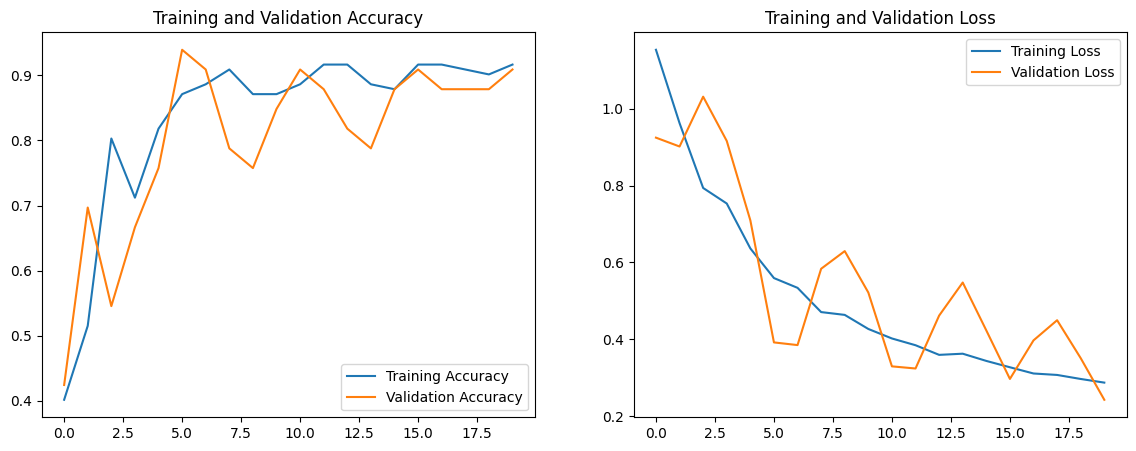

In [15]:
# Visualize loss and accuracy curves
plot_training_history(history_vgg)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  


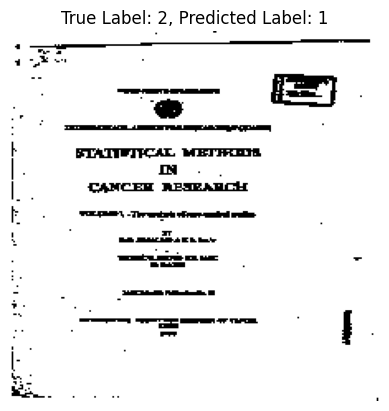

In [16]:
# Get model predictions on the validation dataset
predictions_vgg = model.predict(validation_dataset)
predicted_classes_vgg = np.argmax(predictions_vgg, axis=1)

# Find the indices of misclassified images
misclassified_indices = np.where(predicted_classes_vgg != true_labels)[0]

# Visualize some misclassified images
for i in range(min(num_images_to_visualize, len(misclassified_indices))):
    index = misclassified_indices[i]
    image, label = list(validation_dataset)[0][0][index], list(validation_dataset)[0][1][index]

    plt.imshow(image.numpy().astype("uint8") * 255)
    plt.title(f"True Label: {label.numpy()}, Predicted Label: {predicted_classes_vgg[index]}")
    plt.axis('off')
    plt.show()